In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
#load the dataset
df=pd.read_csv('/content/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [9]:
#feature select
x=df[['Annual Income (k$)','Spending Score (1-100)']]
x

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [10]:
#feature scaling
sc=StandardScaler()
x=sc.fit_transform(x)
x

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

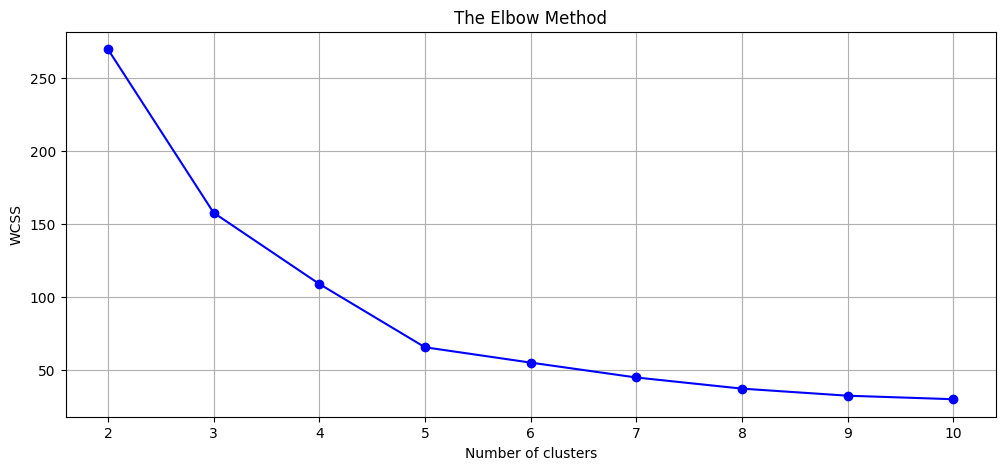

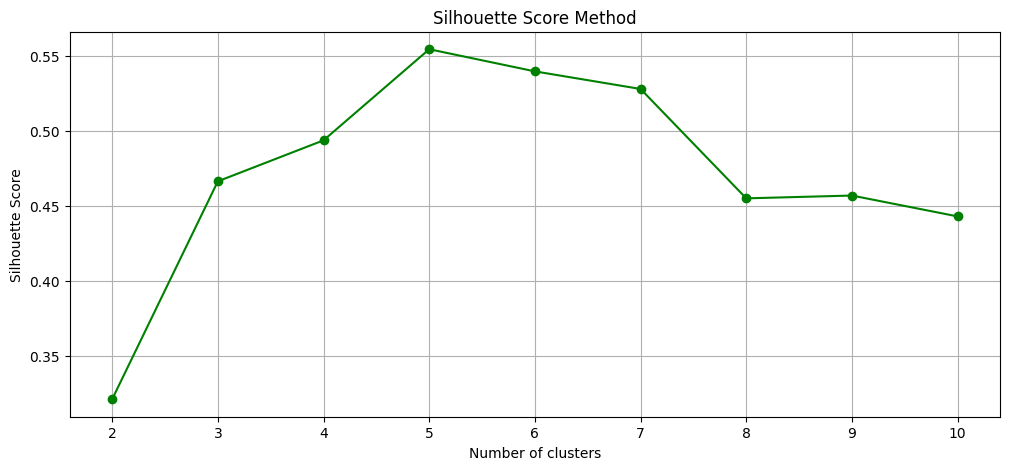

In [12]:
#step2
wcss=[]#within-cluster sum of squares
silhouette_scores=[]
clusters_range = range(2,11) # Iterate from 2 to 10 clusters

for num_clusters in clusters_range:
    kmeans=KMeans(n_clusters=num_clusters,init='k-means++',random_state=42, n_init=10) # Added n_init
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(x,kmeans.labels_))

# Visualize Elbow Method
plt.figure(figsize=(12,5))
plt.plot(clusters_range, wcss, marker='o',color='blue')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(clusters_range)
plt.grid(True)
plt.show()

# Visualize Silhouette Scores
plt.figure(figsize=(12,5))
plt.plot(clusters_range, silhouette_scores, marker='o',color='green')
plt.title('Silhouette Score Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.xticks(clusters_range)
plt.grid(True)
plt.show()

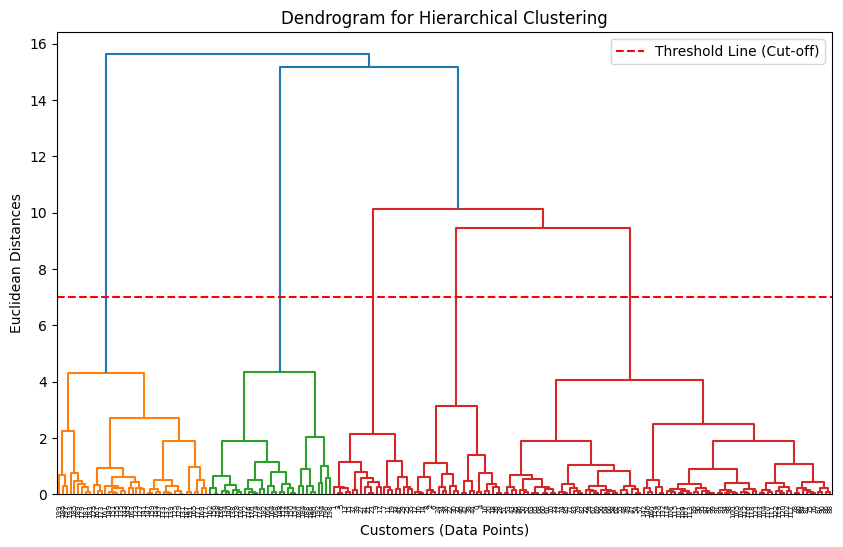

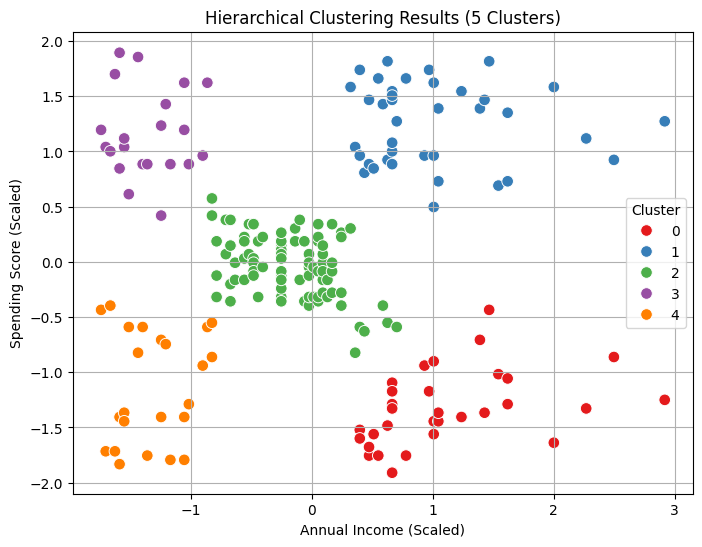

In [14]:
#step 3
# ==========================================
# STEP 3: Hierarchical Clustering (Agglomerative)
# ==========================================

import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# 1. Dendrogram Plot karna (Cluster Mergers visual dekhne ke liye)
plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(x, method='ward'))

plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customers (Data Points)')
plt.ylabel('Euclidean Distances')

# Optimal Threshold Line (Threshold = 7 choose kiya hai 5 clusters ke liye)
plt.axhline(y=7, color='r', linestyle='--', label='Threshold Line (Cut-off)')
plt.legend()
plt.show()

# 2. Agglomerative Hierarchical Clustering Model Apply karna
# Dendrogram ke according distance cutoff 7 par 5 clusters milte hain
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
df['HC_Cluster'] = hc.fit_predict(x)

# 3. Agglomerative Clusters Visualizing
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=x[:, 0],
    y=x[:, 1],
    hue=df['HC_Cluster'],
    palette='Set1',
    s=70
)

plt.title('Hierarchical Clustering Results (5 Clusters)')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

Estimated number of clusters: 7
Estimated number of noise points: 35


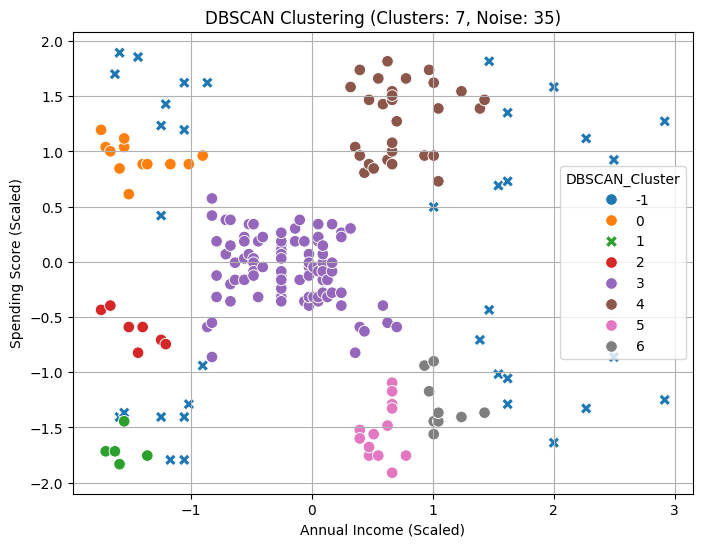

In [16]:
#step 4
# ==========================================
# STEP 4: DBSCAN Algorithm
# ==========================================

from sklearn.cluster import DBSCAN

# 1. DBSCAN Model fit karein (eps aur min_samples experiment karke)
dbscan = DBSCAN(eps=0.3, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(x)

# 2. Core, Boundary, aur Noise Points identify karein
# Noise points/Outliers ko DBSCAN -1 label deta hai
core_samples_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

n_clusters_ = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise_ = list(dbscan.labels_).count(-1)

print(f'Estimated number of clusters: {n_clusters_}')
print(f'Estimated number of noise points: {n_noise_}')

# 3. Visualizing DBSCAN Results
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=x[:, 0],
    y=x[:, 1],
    hue=df['DBSCAN_Cluster'],
    palette='tab10',
    style=(df['DBSCAN_Cluster'] == -1), # Outliers ko alag shape milegi
    s=70
)

plt.title(f'DBSCAN Clustering (Clusters: {n_clusters_}, Noise: {n_noise_})')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.grid(True)
plt.show()

In [18]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans # Import KMeans to define kmeans_final

# Define kmeans_final with the optimal number of clusters (e.g., 5)
# Based on the previous Elbow and Silhouette Score plots, 5 clusters seems optimal.
kmeans_final = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
kmeans_final.fit(x)

# 1. K-Means Metrics
sil_kmeans = silhouette_score(x, kmeans_final.labels_)
db_kmeans = davies_bouldin_score(x, kmeans_final.labels_)

# 2. Hierarchical Clustering Metrics
sil_hc = silhouette_score(x, hc.labels_)
db_hc = davies_bouldin_score(x, hc.labels_)

# 3. DBSCAN Metrics (Excluding noise points '-1' for fair evaluation)
dbscan_mask = dbscan.labels_ != -1
if len(set(dbscan.labels_[dbscan_mask])) > 1:
    sil_dbscan = silhouette_score(x[dbscan_mask], dbscan.labels_[dbscan_mask])
    db_dbscan = davies_bouldin_score(x[dbscan_mask], dbscan.labels_[dbscan_mask])
else:
    sil_dbscan, db_dbscan = np.nan, np.nan

# Summary DataFrame
comparison_df = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical (Agglomerative)', 'DBSCAN'],
    'Silhouette Score (Higher is Better)': [sil_kmeans, sil_hc, sil_dbscan],
    'Davies-Bouldin Index (Lower is Better)': [db_kmeans, db_hc, db_dbscan]
})

print("--- Algorithm Comparison Metrics ---")
print(comparison_df)

--- Algorithm Comparison Metrics ---
                      Algorithm  Silhouette Score (Higher is Better)  \
0                       K-Means                             0.554657   
1  Hierarchical (Agglomerative)                             0.553809   
2                        DBSCAN                             0.524328   

   Davies-Bouldin Index (Lower is Better)  
0                                0.572236  
1                                0.577862  
2                                0.579955  
